# Qwen3.5-4B LetovAI fine-tuning

## Installing libraries

Environment setup for T4 GPU in Google Colab.

In [ ]:
!pip -q install -U unsloth trl datasets accelerate bitsandbytes huggingface_hub sentencepiece matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.

Alternatively, prerequisites for Docker on Ubuntu 24.04 with RTX 4090.

In [ ]:
!pip uninstall -y vllm torchvision torchaudio pandas cuda-bindings

!pip install --no-cache-dir \
    "numpy<2" \
    "typing_extensions>=4.12" \
    "transformers==4.56.2" \
    "trl==0.22.2" \
    "datasets>=3.4.1" \
    "accelerate>=1.0.0" \
    "bitsandbytes>=0.45.0" \
    "huggingface_hub>=0.30.0" \
    "sentencepiece" \
    "pandas>=2.2.0" \
    "peft>=0.15.2" \
    "unsloth_zoo" \
    "unsloth"

## Imports and setup

In [ ]:
import os
import random
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from huggingface_hub import login
from unsloth import FastLanguageModel, is_bfloat16_supported
from trl import SFTTrainer
from transformers import TrainingArguments

from datasets import load_dataset

SEED = 42
DATASET_ID = "pymlex/gr-oborona-lyrics"
BASE_MODEL_ID = "tvall43/Qwen3.5-4B-heretic"
HUB_REPO_ID = "pymlex/qwen3.5-4b-letovai"

random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

/home/coder/python-packages/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
cuda: True
gpu: NVIDIA GeForce RTX 4090


## Dataset

The dataset contains 591 texts related to Letov and his projects.

In [ ]:
raw = load_dataset(DATASET_ID)
print(raw)

DatasetDict({
    songs: Dataset({
        features: ['url', 'title', 'author', 'lyrics', 'album', 'project'],
        num_rows: 591
    })
})


In [ ]:
ds = raw['songs']
ds[2]

{'url': 'https://www.gr-oborona.ru/texts/1056560927.html',
 'title': 'Амнезия',
 'author': 'Е.Летов',
 'lyrics': 'Дружно по тревоге граждане собрали\nТёплые пожитки, ценые предметы\nГромко веселились, после надоело-\nСломаны игрушки, дети наигрались\n\n   Амнезия, амнезия-всё позабыл\n   И мне не страшно\n   Мне теперь не страшно\n   \nДоблестное утро, запах нафталина\nДивная культура, цельная система\nФорменный порядок, стойкий оптимизм\nКто не верит в Бога-тот не станет плакать...\n\n   Амнезия, амнезия-всё позабыл\n   И мне не страшно\n   Мне теперь не страшно\n\nСпелые пельмени, полные карманы\nПолные желудки, массовые сцены\nДырка на ладони — так ему и надо.\nНекому ответить — нечего бояться...\n\n   Амнезия, амнезия-всё позабыл\n   И мне страшно\n   Мне теперь не страшно\n   Мне теперь не страшно\n   Мне теперь не страшно\n   Мне теперь не страшно\n   Мне теперь не страшно',
 'album': 'Так закалялась сталь',
 'project': None}

Selecting only Letov's texts.

In [ ]:
def keep_letov(example):
    author = str(example.get("author", ""))
    return "летов" in author.lower()

ds = ds.filter(keep_letov)
print(len(ds))
ds[0]

319


{'url': 'https://www.gr-oborona.ru/texts/1056560927.html',
 'title': 'Амнезия',
 'author': 'Е.Летов',
 'lyrics': 'Дружно по тревоге граждане собрали\nТёплые пожитки, ценые предметы\nГромко веселились, после надоело-\nСломаны игрушки, дети наигрались\n\n   Амнезия, амнезия-всё позабыл\n   И мне не страшно\n   Мне теперь не страшно\n   \nДоблестное утро, запах нафталина\nДивная культура, цельная система\nФорменный порядок, стойкий оптимизм\nКто не верит в Бога-тот не станет плакать...\n\n   Амнезия, амнезия-всё позабыл\n   И мне не страшно\n   Мне теперь не страшно\n\nСпелые пельмени, полные карманы\nПолные желудки, массовые сцены\nДырка на ладони — так ему и надо.\nНекому ответить — нечего бояться...\n\n   Амнезия, амнезия-всё позабыл\n   И мне страшно\n   Мне теперь не страшно\n   Мне теперь не страшно\n   Мне теперь не страшно\n   Мне теперь не страшно\n   Мне теперь не страшно',
 'album': 'Так закалялась сталь',
 'project': None}

## Examples

In [ ]:
df = ds.to_pandas()[["title", "lyrics"]].dropna().reset_index(drop=True)
df["title"] = df["title"].astype(str).str.strip()
df["lyrics"] = df["lyrics"].astype(str).str.strip()
df.head()

,title,lyrics
0,Амнезия,Дружно по тревоге граждане собрали\nТёплые пож...
1,Анархия,"Это — провокация, это — саботаж\nЛенин гальван..."
2,Анархия (Да будет),Анархисты видят свет\nАнархисты знают рай\nАна...
3,Анархия,На каждого из нас легион ментов\nНа каждого из...
4,Тишина,Я устал от тишины \nТишина свинцовой каст...


## Text length distribution

Basic statistics.

In [ ]:
df["char_len"] = (df["title"] + df["lyrics"]).str.len()
df["char_len"].describe()

count     319.000000
mean      699.714734
std       466.038129
min        50.000000
25%       429.000000
50%       624.000000
75%       898.500000
max      3890.000000
Name: char_len, dtype: float64

Histogram show that the most of the texts are 600 symbols long.

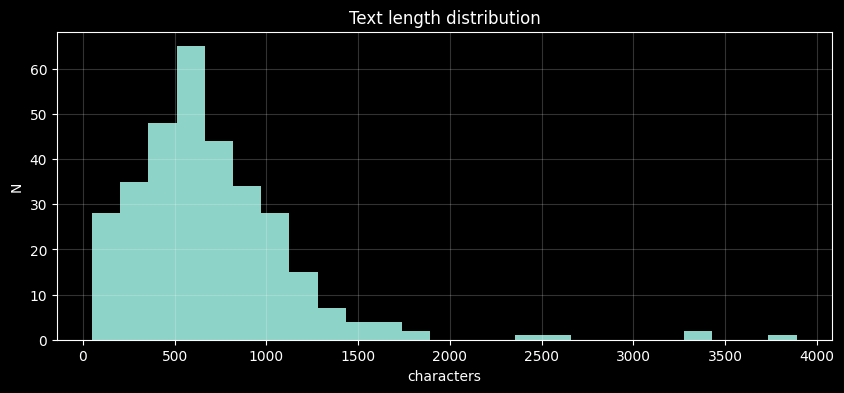

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(df["char_len"], bins=25)
plt.title("Text length distribution")
plt.xlabel("characters")
plt.ylabel("N")
plt.grid(alpha=0.2)
plt.show()

In [ ]:
max_seq_length = 1024

## Training format

We use the Heretic version of Qwen3.5-4b because Letov's texts are usually blocked by the safety policies of standard LLMs.

In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL_ID,
    max_seq_length=max_seq_length,
    dtype=None,
    load_in_4bit=True,
)

EOS_TOKEN = tokenizer.eos_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

==((====))==  Unsloth 2026.4.2: Fast Qwen3_5 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA GeForce RTX 4090. Num GPUs = 1. Max memory: 23.516 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu130. CUDA: 8.9. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 723/723 [00:01<00:00, 403.42it/s]
Unsloth: Warning - VLM processor fallback returned None for model_type=qwen3_5


In [ ]:
SYSTEM_PROMPT = "Ты пишешь только песни и стихи в духе Егора Летова. Отвечай только художественным текстом."

def format_example(example):
    title = str(example["title"]).strip()
    lyrics = str(example["lyrics"]).strip()

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": f"Напиши песню или стихотворение.\nТема: {title}\nПиши только текст.",
        },
        {"role": "assistant", "content": lyrics},
    ]

    return {"text": tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)}

train_ds = Dataset.from_pandas(df[["title", "lyrics"]], preserve_index=False)
train_ds = train_ds.map(format_example, remove_columns=train_ds.column_names)

print(train_ds[0]["text"][:2000])

Map: 100%|██████████| 319/319 [00:00<00:00, 3263.95 examples/s]

<|im_start|>system
Ты пишешь только песни и стихи в духе Егора Летова. Отвечай только художественным текстом.<|im_end|>
<|im_start|>user
Напиши песню или стихотворение.
Тема: Амнезия
Пиши только текст.<|im_end|>
<|im_start|>assistant
<think>

</think>

Дружно по тревоге граждане собрали
Тёплые пожитки, ценые предметы
Громко веселились, после надоело-
Сломаны игрушки, дети наигрались

   Амнезия, амнезия-всё позабыл
   И мне не страшно
   Мне теперь не страшно
   
Доблестное утро, запах нафталина
Дивная культура, цельная система
Форменный порядок, стойкий оптимизм
Кто не верит в Бога-тот не станет плакать...

   Амнезия, амнезия-всё позабыл
   И мне не страшно
   Мне теперь не страшно

Спелые пельмени, полные карманы
Полные желудки, массовые сцены
Дырка на ладони — так ему и надо.
Некому ответить — нечего бояться...

   Амнезия, амнезия-всё позабыл
   И мне страшно
   Мне теперь не страшно
   Мне теперь не страшно
   Мне теперь не страшно
   Мне теперь не страшно
   Мне теперь не страшн

## LoRA

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Unsloth: Making `model.base_model.model.model.language_model` require gradients


In [ ]:
model.print_trainable_parameters()

trainable params: 21,233,664 || all params: 4,560,499,200 || trainable%: 0.4656


## Training

In [ ]:
from trl import SFTConfig, SFTTrainer

sft_config = SFTConfig(
    output_dir="qwen3_5_4b_letovai_unsloth",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=8,
    learning_rate=1e-6,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,
    save_strategy="no",
    report_to="none",
    fp16=not is_bfloat16_supported(),
    bf16=is_bfloat16_supported(),
    optim="adamw_8bit",
    max_grad_norm=1.0,
    remove_unused_columns=False,
    seed=SEED,
    max_seq_length=max_seq_length,
    packing=True,
    dataset_text_field="text",
)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_ds,
    args=sft_config,
)

trainer.train()


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Sample packing skipped (vision-language model detected).


Unsloth: Tokenizing ["text"] (num_proc=20): 100%|██████████| 319/319 [00:06<00:00, 47.23 examples/s]
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 319 | Num Epochs = 1 | Total steps = 5
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 8 x 1) = 64
 "-____-"     Trainable parameters = 21,233,664 of 4,560,499,200 (0.47% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,1.753139
2,1.717386
3,1.745798
4,1.802573
5,1.750769


TrainOutput(global_step=5, training_loss=1.7539331674575807, metrics={'train_runtime': 43.5188, 'train_samples_per_second': 7.33, 'train_steps_per_second': 0.115, 'total_flos': 4000654171637760.0, 'train_loss': 1.7539331674575807})

## Saving and pushing to Hub

In [ ]:
HF_TOKEN = 'YOUR_TOKEN'
!hf auth login --token "$HF_TOKEN"

A new version of huggingface_hub (1.9.0) is available! You are using version 1.4.1.
To update, run: pip install -U huggingface_hub

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: write).
The token `040426` has been saved to /home/coder/.cache/huggingface/stored_tokens
Your token has been saved to /home/coder/.cache/huggingface/token
Login successful.
The current active token is: `040426`


In [ ]:
trainer.model.save_pretrained("letovai_lora")
tokenizer.save_pretrained("letovai_lora")

trainer.model.push_to_hub(HUB_REPO_ID)
tokenizer.push_to_hub(HUB_REPO_ID)

print("pushed to:", HUB_REPO_ID)

Processing Files (1 / 1): 100%|██████████| 85.0MB / 85.0MB, 12.5MB/s  
New Data Upload: 100%|██████████| 84.9MB / 84.9MB, 12.5MB/s  


Saved model to https://huggingface.co/pymlex/qwen3.5-4b-letovai


Processing Files (1 / 1): 100%|██████████| 20.0MB / 20.0MB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


pushed to: pymlex/qwen3.5-4b-letovai


## Inference

In [ ]:
from peft import PeftModel
from unsloth import FastLanguageModel
import torch

BASE_MODEL_ID = "tvall43/Qwen3.5-4B-heretic"
ADAPTER_ID = "pymlex/qwen3.5-4b-letovai"

max_seq_length = 2048

base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL_ID,
    max_seq_length=max_seq_length,
    load_in_4bit=True,
    dtype=None,
)

model = PeftModel.from_pretrained(base_model, ADAPTER_ID)
model = FastLanguageModel.for_inference(model)

/tmp/ipykernel_3263/2680377738.py:2: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.4: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.


model.safetensors:   0%|          | 0.00/9.08G [00:00<?, ?B/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

...

chat_template.jinja: 0.00B [00:00, ?B/s]

Unsloth: Warning - VLM processor fallback returned None for model_type=qwen3_5


tokenizer.json:   0%|          | 0.00/20.0M [00:00<?, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/85.0M [00:00<?, ?B/s]

In [ ]:
SYSTEM_PROMPT = "Ты пишешь только песни и стихи в духе Егора Летова. Отвечай только художественным текстом."

def generate_letov_song(title, max_new_tokens=1536, temperature=0.9, top_p=0.95):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": f"Напиши песню или стихотворение.\nТема: {title}\nПиши только текст.",
        },
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            repetition_penalty=1.1,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

print(generate_letov_song("Будущее матушки Руси"))

Загадаю,чтобы сбылось!-будет-
Крупный пожар над Москвой-градом
Завтра,завтра,-полный разгром 
А завтра будет новый крест и кривой шов 
И ещё-ещё... 

     Но ведь это всё-только начало 
       И наступит-непременно
      Время наций-проклятых.
     А потом придёт-пожалуй 
       Злобная зима 
       Чтобы погрузить нас в вечную тишину
        И слепую глушь
         Где на всех лицах зарастают морщины...
          Где мы будем ждать-
            Как будто мы никогда не рождались...


       Мы родимся вновь!
       Родимся снова!
       Так зачем нам жажда?


In [ ]:
print(generate_letov_song("Шаман"))

Снег,соль и кровь в висках-а не я!
Под землей шипят червячки-я их знаю!
А по рощице,как по горло идет-шарит
По земле руками и тупо смотрит...

         Вот так.Так вот.Какое чудо?Кто ты?
         Кто утратил разум?Что с тобой?
         Кто утратил рассудок?Восклицай громче!
         Воскличай громче и кричи больше!
         
О нет,не то!Не каталось на мусорке
По моим мозгам—нахуённая гребаная 
         Нафиг,почему так тихо?
         Не спится?!
         Где же тогда мой брат-мой верный шариш?


Remembers of «Мёртвые» (1994).

In [ ]:
print(generate_letov_song("Красная речка"))

На горе,как ты умирать научился— 
Так и живи на свете.
        Живой умирать научился—
        
        Он умирает во сне,
        Так и живу на свете,
        Живой умирать научился--
        Так и живу на свете!
      
Зеленая река,она течет и каяется.
         
        Зелень-та в немом горле нехрипящей.
        
        А кто его-то знает?Кто их-то знает?
            
              Они ведь никогда никого не знают...
             Они никогда никого не знают...
           Они никогда никого не знают...

Голубое небо оно стоит.
           
         Оно там так высоко поднялось—
         Как насмерть на землю прильнуло и застыло.
            
            На земле,где все-таки земля,
                Где всё же вся-что земля...


In [ ]:
print(generate_letov_song("Ёлки-палки"))

Ёлки-палки, ёлки-ветки—
А на том конце рождаются дети

Ёлки-палки, ёлки-ветки—
Пой, моя душа,пой,свой палец зажат!

Ёлки-палки,ёлки-ветки—
Я не люблю поганых ветвей и поганных елок—
На тех кончиках мне рождаются дети.

Ёлки-палки,яблочки-капельки —
Ноги ходят вдоль стены,а глаза горят огнём!

Ёлки-палки,ёлочки-чепчики —
Моей груди пока нет места для твоих детей.


Compare with «Детский мир» (1985): «Я стрельну себе в висок — потекёт весёлый сок».

In [16]:
print(generate_letov_song("Анархия"))

Однажды ночью в амазонской джунглях 
Я увидел как тролли просят хлеб
В тот момент меня разрывало на части
Как вырвало из горла яд
Взрывной звук сбидался под пальто 
И он не знал что это за звери
Но знал что это их дети
Поэтому он плакал о своих детях...

        Потому,потому...
            потому,потому...
                 потому,потому...
          потому,потому...
                 потому,потому...

         Мы бросаем камни
                  в окна издалека

Я смотрел,как в луже крови
Говорили о новом дне
Прозрачные лица горели огнём
Мирное небо над головой
Несчастные деревья плакали слёзами
А убитые дети шли по земле
Рассматривая свои пальцы
Подождите...подождите....

        Потому,потому...
            потому,потому...
                 потому,потому...
          потому,потому...
                 потому,потому...

     Мы роняем звонкие предметы
             на землю

Умершие глаза сверкнули огнём
Тело умерло в луже крови
Чьи-то горячие руки сжали мою шею
Заносило обону смерти
Слу

In [45]:
print(generate_letov_song("Анархия"))

Будить себя на ранний закат.
Отмывать себя от гравия.
Загрязнять себя,
Всё это — анархия.

Вонять из-под ногтей.
Выпускать в окно,
Освобождаясь.
Анархия — это не то, что мы думали.

Садиться в автобус.
Держаться за спинки сидений,
Жадно дышать,
Залезать в свой труп.

Это не значит идти с крестом на смерть.
Это значит убивать врагов.

Кусая пальцы,
Мой руки,
Рисовать руками лицо,
Сгибая пальцы.


In [ ]:
print(generate_letov_song("Не коли дрова"))

На гребёнке снег не тает
Словно вата,а на земле кривые дорожки
На деревенских улицах сиротская зима
Зимовка,завтрак,время спать,накрываю рот
        Но коли дрова-то....

В лесной дали ветер кружится,как метелица
По льду оброненой жизни покатился следок
Почему ты,не глядя на меня,забыл про нас
Лесная тайга,лесная шпала,столько раз...
        А коли дрова...

Далеко за речкой плывает пугливое стадо
Далеко от дома забрела с утра сама
Наступит зима,вымокнет земля,замерзнет трава
Стальное небо повисло над головой
        Если бы дрова-то...

Голубая поляна рассыпана дождём
Снежная корка под сырой мокрой травой
Отсюда слышно далеко как издалёка звонят
Однажды выйдя рано утром,выходишь поздно 
        Только если б дрова...


In [17]:
print(generate_letov_song("Черный флаг"))

Деньги-деньшки-руки-ногти-косточки-голые ноги—
Мир во всём — вешай чёрный флаг! 
Кто не понял — тот не прочитал
Кто сошёл с ума — того никто не понял

А всё это лишь одна история про одну картину
И кто не видит — тот один-дважды смотрел —
Зеркала на стенах,на стене зеркало...
Никто не знает,кто это сказал
Но зато мы можем смеяться вместе до смерти
А ещё можем плакать,пока горят глаза
Копать землю с утра до ночи
Жить среди мертвецов и гадостей
Словно в пучине воды
Прокладывая себе дорогу с помощью рук
Через голову и вниз ногами

Впереди война,победа или смерть
Впереди война, победа или смерть!
Мы будем помнить наши святые имена!
Через голову и сквозь стены
Через голову и сквозь стены!


In [19]:
print(generate_letov_song("Всё идёт по п..."))

Скажу — всё идёт по плану,
Всё идёт по плану—
Нет ничего сложного,
Ничего не сложно.

Забудь-то про проблемы,
Принеси мне конфеты,
Не забудь подогреть молоко на кухне,
Чтобы всё было так!

Знаешь,что я говорю?
Однажды в этом мире
Мы ещё разок поправимся и пообещаем стать такими же, как раньше
Да—все будут все такие же как раньше!

А теперь давай сойдём на кухню,
У нас крестик да ноль,
Если мы сойдет с ума,
То нас там никто не найдёт!

Все счастливы,как собаки,
Генералы танкуются,
Иногда-неплохо поспать,
Ну а потом снова танцевать!

Но что бы ни случилось,
Все будет так,как надо,
Бедные люди
Мирно лягут спать.


In [28]:
print(generate_letov_song("По ком плачут скоморохи"))

Смех на уста,но душа пуста
Улыбка беззубая,как калёная сталь
Острый взгляд —и в глаза огонь
Полноценное небо на земле неба не видно
    По ком плачут скоморохи ? 

Белыми зубами рвут глотку слова
Душевно-бессильные мысли о полёте
На языке укус - это правда
В глазах обидный осадок - это правда
Смеётся сам себя скоморох... 
    По ком плачут скоморохи ?
             Кто бы их спас? 

Звоны разбитых колоколов
Странствия бесконечные ночи
Мрачные заклинания,позабытые слова
Искры из глаз сжигают гордую пыль

Я буду говорить со всеми-только
Будем пить до смерти
Но все бегут назад в свои жилища
Под завистливые шмыгающие крылья мух.
    По ком плачут скоморохи? 
             Кто бы их спас ?


In [26]:
print(generate_letov_song("Сталинская финка"))

Невозмутимая,неизбежная
Волна подступает-
Бесконечный день впереди.. 
   У нас сегодня опять праздник
   Мы вместе не разбивались...
   Нам все ещё повезёт
   Нас будет на земле-
    Будущее-конец!

Стойкое чувство суровой логики
Становится ясно
Какое место он займет...
   А поэт извинился 
   Словно вдруг что случилось
   Он снова засмеялся 
   И стал писать стихи...
      Как обычно бывает

Где-то вдали разгорается затишье 
Далекое отчаяние 
Очередная попытка взойти сюда
     Вы не должны знать ничуть
     Пусть вы будете рады
     Потому что я здесь -
       Для вас это закон!

Завтра утром вы начнёте собирать 
Урожай и жить счастливо
Вы уже научитесь любить друг друга
     Бросьте всё,что мешает 
     Если вам покажется 
     Это слишком трудное дело
     Вот и наступит конец-
        Заступает новая пора
 
Невозмутимая,неизбежная
Волна подступает-
Всякий раз она возвращается
   Я за неё со мной.
   В ней столько радости
   И какой весёлой жизни-
   Я для неё готовый!
         Для 

In [31]:
print(generate_letov_song("Уютные колья"))

Я подставлю тебе шею-свободу
Берёшь,как елка у ворот

        Уютные колья!

             Я подставлю тебе шею-свободу
            И ты будешь танцевать под мой взгляд 
    Уютные колья!     Уютные колья!


И если когда-нибудь мне захочется 
Кто-нибудь мне на помощь-я найду его
Далеко я не пойду,если будет что-что 
       Будет так-будет так-что

        Уютные колья!

             Я подставлю тебе шею-свободу
            На меня никто не похож 
                Уютные колья!      Уютные колья!

И если когда-нибудь мне захочется
Помочь-кто-то мне поможет-кто-нибудь поможет?
А может-попробовать-на всякий случай
             Кому как надо-кому как нужно...

         Уютные колья!

             Я подставлю тебе шею-свободу
               И ты будешь танцевать под мой взгляд 
                 Уютные колья!      Уютные колья!


In [30]:
print(generate_letov_song("Песня чекиста"))

Строчка во сне,во сне...
Впереди пойдёт снег 
Потому что нарядились Чекисты
Стань чекистом — будь чётким,будь быстрым!
Чешка во сне...
Господи!Что случилось?
Проснулся я 
Не плачь ...
Хорошо
Я просто проспал
Я думал — я задремал...
Боялся разбудить
А вот и не дурно-сплющил...
Сегодня чекист в армии,а вчера
Чекист,чекист,чекист!
У нас у всех одна мысль,а мы друг друга
Мы разные
Иногда мы даже не знаем 
Кто мы такие
И часто бывает так,что мы до сих пор 
Остановились
Задержались где то 
Перед нами дорога
Впереди пойдёт снег
Потому что нарядились Чекисты...


In [39]:
print(generate_letov_song("Потерянный наручник"))

Умирает на земле -накапливается мусор,
Безобразный мир,который я вижу сейчас...
       Потерянный наручник-это пирожное,
       Потерянный наручник-это левитатор...

Слишком уж поганая гнилая туповатость,
Разве не видать?..Волны,как будто мы их видим!
       Потерянный наручник-это паста-пестрая,
       Потерянный наручник-это коньки-сочные...

Я помню как в лесу был нахоженный наводчик,
Он очень устал,он уже почти сошёл с ума,
       Потерянный наручник-это пивная кружка,
       Потерянный наручник-это хлеб из магазина...

А вот теперь я стою среди кустов и плачу,
Вырастает из них-огромная грязная туча,
       Потерянный наручник-это пчела-околошумно,
       Потерянный наручник-это глоток аэрозоля...

       Потерянный наручник-это пёстрый паштет
       Потерянный наручник-это пеленальный лист
       Потерянный наручник-это падающий снег
       Потерянный наручник-это парализующая боль...


In [35]:
print(generate_letov_song("Звонок комиссара"))

Звонок комиссара,звонок комиссаровзяться за то что ты делал
Звонок комиссара—конец звенит
        На все вопросы отвечай:да-да-да
        На всё вопросы отвечай—да-да-да
 
Нужно тебе—нужно кому-нибудь
        И это не меня не волнуется
        Ничего не волнуют тебя

Звонок комиссара-это очень весело
        Это так круто а ещё и хорошо!
        Все мы должны ответить:да да да
        На все вопросы отвечать —да -да-да
 
Сегодня день рождения для всех нас
        Никто нам не мешает на радость другим
        Нам всем хочется сказать: да, да да
        Нам всем хочется кричать-да,да-да


In [43]:
print(generate_letov_song("Сибирская зима"))

В лесу,где снег упал 
Дорога превратилась в реку
Я не суюсь в воду,я держусь за лёд
А мне по пояс в ледяной воде 

   Сибирской зиме  я подчинён

Знаю — я всё время на морозе
Но как только выйду из дома
То вся жизнь моя станет вечной осенью
Если бы меня туда не забрали 

   Сибирской зимой я в панике

В лесу,где снег упал
Дорога превратилась в реку 
Я не суюсь в воду,я держусь за лёд
А мне по пояс в ледяной воде 

   Сибирской зиме  я подчинён
    Времени не много,но и места тоже...
